# 🏭 RECYCLE NET — INTELLIGENT WASTE CLASSIFICATION SYSTEM

## Objective

Build an automatic urban-waste classification system using convolutional neural networks and computer vision.

The dataset is composed of 9 categories: glass, paper, cardboard, plastic, metal, general waste, battery, biological and textile.

## Pipeline

1. **Loading and organization** of the unified dataset from two Kaggle sources.
2. **Class-balance analysis** with plots and statistics.
3. **Stratified split** into train / validation / test.
4. **Semantic segmentation** with GrabCut to isolate the main object.
5. **Preprocessing and data augmentation** with split-specific transforms.
6. **Final verification** of the pipeline by visualizing batches.

---
## Libraries and Reproducible Setup

In [1]:
import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

import cv2
import kagglehub

In [2]:
# We fix a global seed to ensure reproducibility in
# splitting, random augmentations and any stochastic operation.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed set: {SEED}")
print(f"Device: {DEVICE}")

Seed set: 42
Device: cpu


---
## a) Dataset Loading and Organization

Two public Kaggle datasets are combined to widen the diversity and number of classes:

| Dataset | Kaggle source | Original classes |
|---|---|---|
| `dataset_base` | `zlatan599/garbage-dataset-classification` | glass, paper, cardboard, plastic, metal |
| `dataset_industrial` | `mostafaabla/garbage-classification` | 12 subcategories (brown-glass, clothes, battery, etc.) |

Both are mapped to 9 unified classes. The `trash` class from the first dataset is discarded because the second dataset splits those images into more specific categories.

### Folder structure
```
dataset_root/
└── <class>/
    ├── img001.jpg
    ├── img002.jpg
    └── ...
```
Each subfolder represents a class. It is traversed with `os.walk` to collect paths and label indices.

### Dataset class
A `UnifiedGarbageDataset` class is implemented, inheriting from `torch.utils.data.Dataset`. At this stage it returns the image as a PIL object without transforms, which lets us reuse it for exploratory analysis, segmentation and later wrapping with transforms.

In [3]:
# "local": uses the folders generated by scripts/download_dataset.py
# "online": downloads / uses the kagglehub cache
EXECUTION_MODE = "local"

if EXECUTION_MODE == "local":
    print("📦 Using local datasets...")
    path_ds1 = os.path.abspath("../data/raw/garbage-dataset-classification")
    path_ds2 = os.path.abspath("../data/raw/garbage-classification")
else:
    print("📦 Downloading Dataset 1 (Base)...")
    path_ds1 = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")

    print("📦 Downloading Dataset 2 (Industrial)...")
    path_ds2 = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("\n✅ Paths configured.")
print(f"📍 Dataset 1 path: {path_ds1}")
print(f"📍 Dataset 2 path: {path_ds2}")

📦 Downloading Dataset 1 (Base)...


100%|██████████| 121M/121M [00:10<00:00, 12.0MB/s] 

Extracting files...


📦 Downloading Dataset 2 (Industrial)...


100%|██████████| 239M/239M [00:20<00:00, 12.4MB/s] 

Extracting files...



✅ Paths configured.
📍 Dataset 1 path: /home/carlos/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5
📍 Dataset 2 path: /home/carlos/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1


In [4]:
# Target classes with their numeric index
TARGET_CLASSES = {
    "glass":      0,
    "paper":      1,
    "cardboard":  2,
    "plastic":    3,
    "metal":      4,
    "trash":      5,
    "battery":    6,
    "biological": 7,
    "textile":    8
}

# Inverse dictionary for visualizations
IDX_TO_CLASS = {
    0: "Glass",
    1: "Paper",
    2: "Cardboard",
    3: "Plastic",
    4: "Metal",
    5: "General Waste",
    6: "Battery",
    7: "Biological",
    8: "Textile"
}

# Per-source mapping configuration
DATASETS_CONFIG = [
    {
        "name": "dataset_base",
        "path": path_ds1,
        "mapping": {
            "glass":     "glass",
            "paper":     "paper",
            "cardboard": "cardboard",
            "plastic":   "plastic",
            "metal":     "metal",
            "trash":     None       # discarded due to ambiguity
        }
    },
    {
        "name": "dataset_industrial",
        "path": path_ds2,
        "mapping": {
            "brown-glass":  "glass",
            "green-glass":  "glass",
            "white-glass":  "glass",
            "paper":        "paper",
            "cardboard":    "cardboard",
            "plastic":      "plastic",
            "metal":        "metal",
            "battery":      "battery",
            "biological":   "biological",
            "clothes":      "textile",
            "shoes":        "textile",
            "unknown":      None,     # discarded
            "food-waste":   None      # discarded
        }
    }
]

print(f"Target classes: {list(TARGET_CLASSES.keys())}")

Target classes: ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash', 'battery', 'biological', 'textile']


In [5]:
class UnifiedGarbageDataset(Dataset):
    """
    Unified dataset that combines multiple sources with class mapping.
    Returns untransformed PIL images to allow flexibility in
    exploration, segmentation and later wrapping with transforms.
    """

    def __init__(self, datasets_config):
        self.samples = []  # list of (image_path, label_int)
        for ds_cfg in datasets_config:
            self._load_dataset(ds_cfg)

    def _load_dataset(self, ds_cfg):
        dataset_path = ds_cfg["path"]
        mapping = ds_cfg["mapping"]

        for root, dirs, files in os.walk(dataset_path):
            class_name = os.path.basename(root).lower()

            if class_name not in mapping:
                continue

            target_class = mapping[class_name]

            if target_class is None:  # explicitly ignored class
                continue

            target_label = TARGET_CLASSES[target_class]

            for file in files:
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append(
                        (os.path.join(root, file), target_label)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        return image, label


full_dataset = UnifiedGarbageDataset(DATASETS_CONFIG)
print(f"✅ Unified dataset: {len(full_dataset)} total images")

✅ Unified dataset: 26219 total images


---
## Dataset Balance Analysis

Before splitting, we analyze the class distribution in order to:
- Detect imbalance that could bias training.
- Justify the use of a **stratified** split.
- Decide whether additional techniques such as oversampling or class weights are needed.

In [6]:
# Sample count per class
all_labels = [label for _, label in full_dataset.samples]
label_counts = pd.Series(all_labels).value_counts().sort_index()

class_names  = [IDX_TO_CLASS[i] for i in label_counts.index]
counts       = label_counts.values
total        = counts.sum()
percentages  = counts / total * 100

# Summary DataFrame
df_balance = pd.DataFrame({
    "Class":      class_names,
    "Index":      label_counts.index,
    "Count":      counts,
    "Percentage": percentages.round(2)
})
print("=== Full dataset distribution ===")
print(df_balance.to_string(index=False))
print(f"\nTotal images: {total}")
print(f"Most frequent class: {class_names[counts.argmax()]} ({counts.max()} imgs)")
print(f"Least frequent class: {class_names[counts.argmin()]} ({counts.min()} imgs)")
print(f"Max/min ratio: {counts.max()/counts.min():.1f}x")

=== Full dataset distribution ===
     Class  Index  Count  Percentage
     Glass      0   4511       17.21
     Paper      1   3365       12.83
 Cardboard      2   3105       11.84
   Plastic      3   3153       12.03
     Metal      4   2853       10.88
   Battery      6    945        3.60
Biological      7    985        3.76
   Textile      8   7302       27.85

Total images: 26219
Most frequent class: Textile (7302 imgs)
Least frequent class: Battery (945 imgs)
Max/min ratio: 7.7x


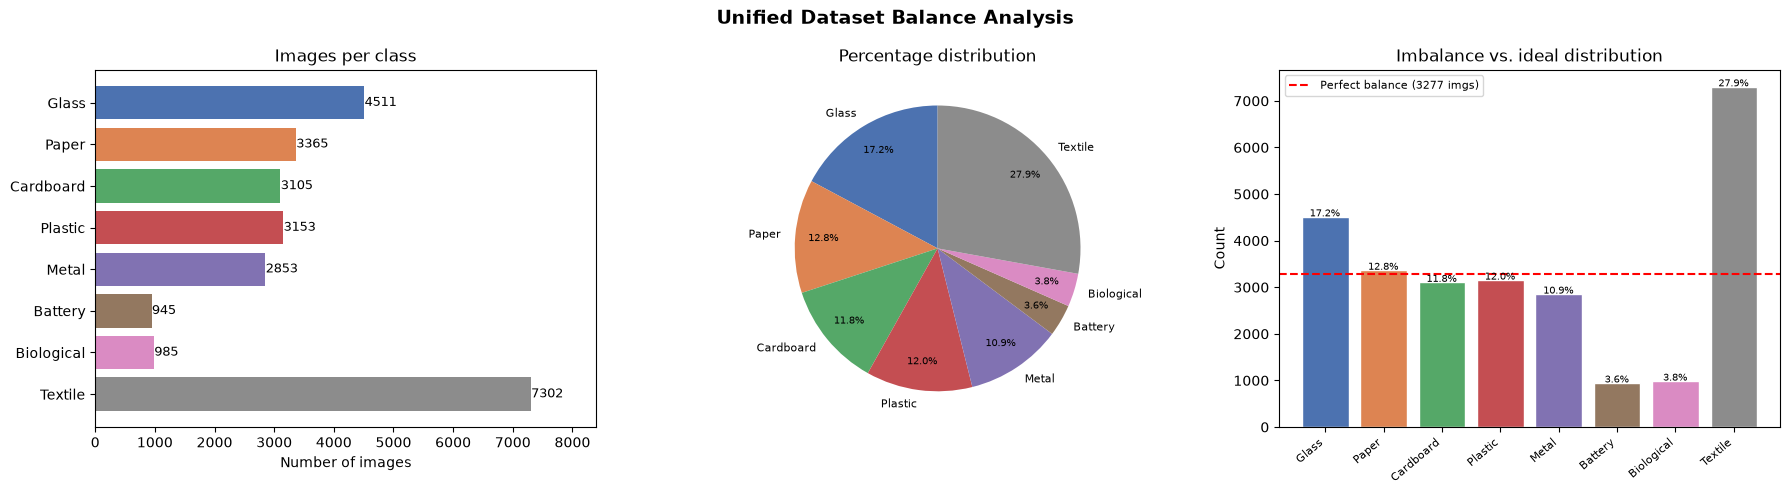


📊 The dataset shows moderate-to-high imbalance.
   → The stratified split will preserve the proportions in each split.


In [7]:
COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Unified Dataset Balance Analysis", fontsize=14, fontweight="bold")

# --- Plot 1: Horizontal bars with counts ---
ax = axes[0]
bars = ax.barh(class_names, counts, color=COLORS)
ax.set_xlabel("Number of images")
ax.set_title("Images per class")
ax.invert_yaxis()
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{count}", va="center", fontsize=9)
ax.set_xlim(0, counts.max() * 1.15)

# --- Plot 2: Pie chart with percentages ---
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts,
    labels=class_names,
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    pctdistance=0.8
)
for text in texts:
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_fontsize(7)
ax.set_title("Percentage distribution")

# --- Plot 3: Vertical bars with a perfect-balance line ---
ax = axes[2]
x = range(len(class_names))
bars2 = ax.bar(x, counts, color=COLORS, edgecolor="white")
ax.axhline(y=total/len(class_names), color="red", linestyle="--",
           linewidth=1.5, label=f"Perfect balance ({int(total/len(class_names))} imgs)")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax.set_title("Imbalance vs. ideal distribution")
ax.legend(fontsize=8)
for bar, pct in zip(bars2, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{pct:.1f}%", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

print("\n📊 The dataset shows moderate-to-high imbalance.")
print("   → The stratified split will preserve the proportions in each split.")

---
## Visual Dataset Exploration

Random sampling of images to check visual diversity: variability in lighting, orientation, background and object size.

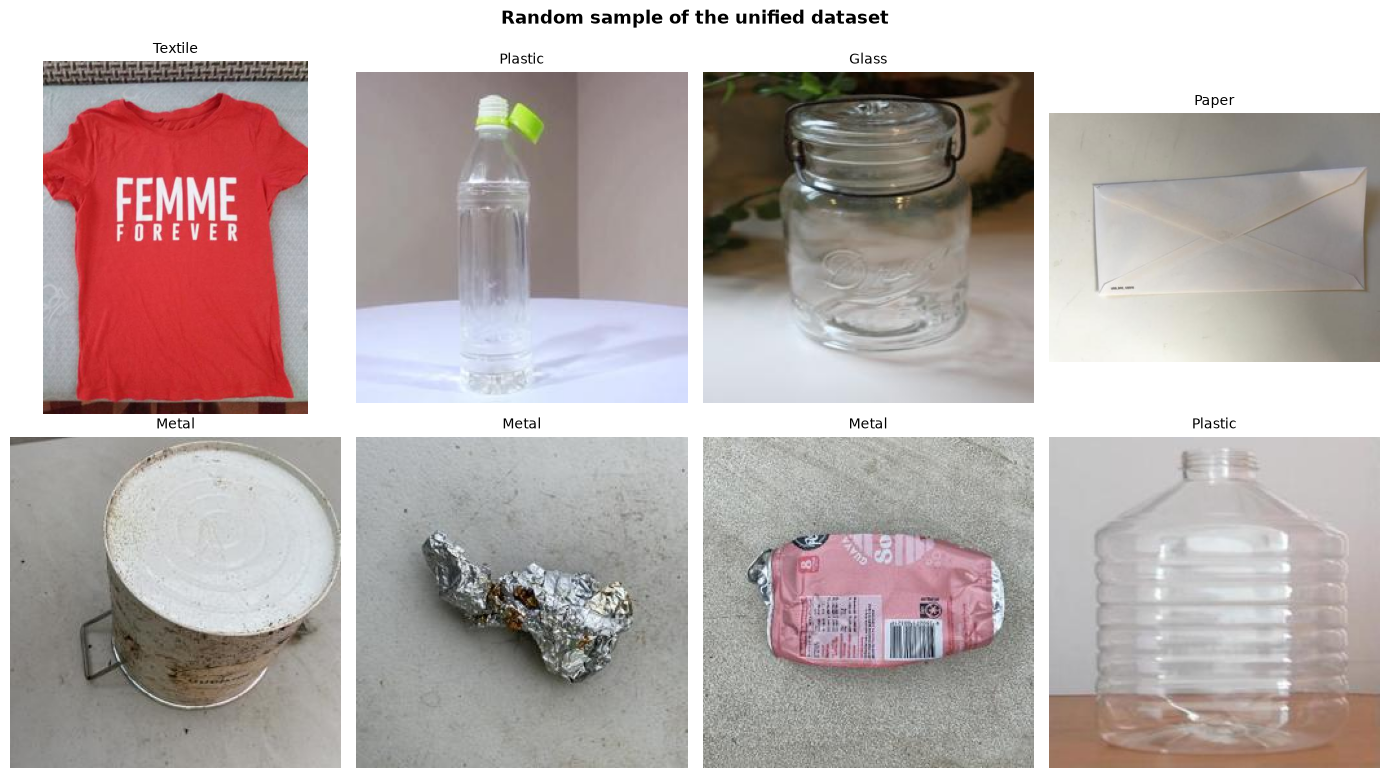

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
fig.suptitle("Random sample of the unified dataset", fontsize=13, fontweight="bold")

for ax in axes.flatten():
    idx = random.randint(0, len(full_dataset) - 1)
    image, label = full_dataset[idx]
    ax.imshow(image)
    ax.set_title(IDX_TO_CLASS[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## b) Dataset Splitting

### Criterion
A **stratified split** (`stratify=labels`) is used to ensure every split keeps the same class distribution as the full dataset. This is essential given the observed imbalance: without stratification, minority classes could be underrepresented or absent in validation/test.

### Proportions
- **Train**: 80% of the total
- **Validation**: 10% of the total
- **Test**: 10% of the total

`random_state=SEED` is set in both splits for full reproducibility.

In [9]:
indexes = list(range(len(full_dataset)))
labels  = [full_dataset[i][1] for i in indexes]

# First split: train (80%) vs temp (20%)
train_idx, temp_idx = train_test_split(
    indexes,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

# Second split: val (10%) vs test (10%) — half of temp
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print("=== Split distribution ===")
print(f"  Train:      {len(train_idx):>5} images  ({len(train_idx)/len(indexes)*100:.1f}%)")
print(f"  Validation: {len(val_idx):>5} images  ({len(val_idx)/len(indexes)*100:.1f}%)")
print(f"  Test:       {len(test_idx):>5} images  ({len(test_idx)/len(indexes)*100:.1f}%)")
print(f"  Total:      {len(indexes):>5} images")

=== Split distribution ===
  Train:      20975 images  (80.0%)
  Validation:  2622 images  (10.0%)
  Test:        2622 images  (10.0%)
  Total:      26219 images


In [10]:
# Per-class distribution in each split
def count_by_class(idx_list, all_labels):
    counts = {i: 0 for i in range(len(TARGET_CLASSES))}
    for i in idx_list:
        counts[all_labels[i]] += 1
    return counts

train_counts = count_by_class(train_idx, labels)
val_counts   = count_by_class(val_idx,   labels)
test_counts  = count_by_class(test_idx,  labels)

df_splits = pd.DataFrame({
    "Class":      [IDX_TO_CLASS[i] for i in range(len(TARGET_CLASSES))],
    "Train":      [train_counts[i] for i in range(len(TARGET_CLASSES))],
    "Validation": [val_counts[i]   for i in range(len(TARGET_CLASSES))],
    "Test":       [test_counts[i]  for i in range(len(TARGET_CLASSES))]
})

print("=== Images per class and split ===")
print(df_splits.to_string(index=False))

=== Images per class and split ===
        Class  Train  Validation  Test
        Glass   3609         451   451
        Paper   2692         336   337
    Cardboard   2484         311   310
      Plastic   2522         316   315
        Metal   2282         285   286
General Waste      0           0     0
      Battery    756          95    94
   Biological    788          98    99
      Textile   5842         730   730


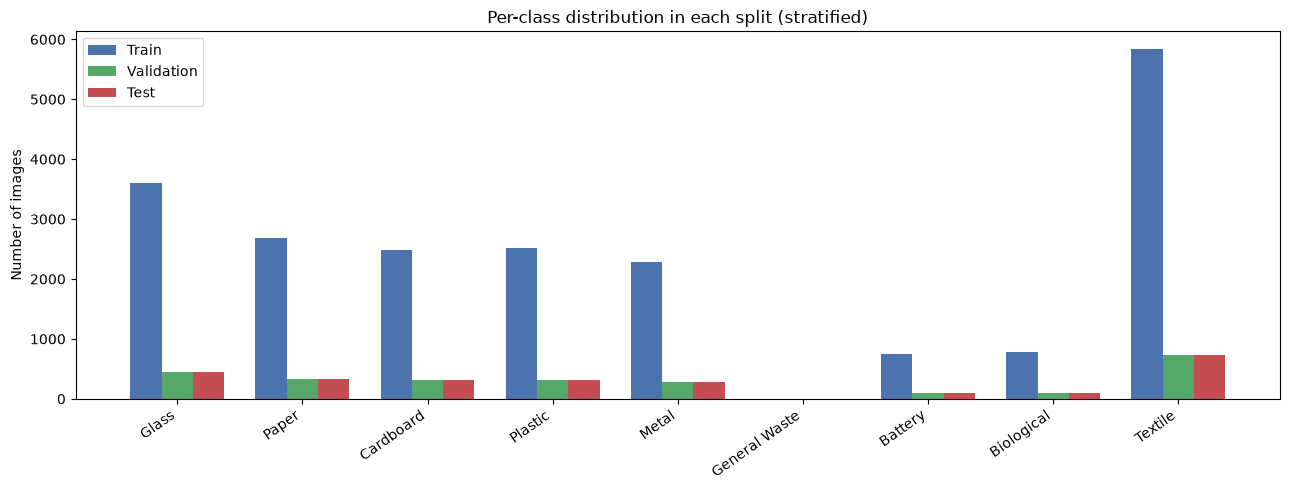

In [11]:
# Visualization of the stratification
x         = np.arange(len(TARGET_CLASSES))
width     = 0.25
class_labels = [IDX_TO_CLASS[i] for i in range(len(TARGET_CLASSES))]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, df_splits["Train"],      width, label="Train",      color="#4C72B0")
ax.bar(x,         df_splits["Validation"], width, label="Validation", color="#55A868")
ax.bar(x + width, df_splits["Test"],       width, label="Test",       color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=35, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Per-class distribution in each split (stratified)")
ax.legend()
plt.tight_layout()
plt.show()

---
## c) Semantic Segmentation with GrabCut

Before the classification preprocessing, semantic segmentation is applied using `grabCut`. The goal is to mask out the background and keep only the main object, reducing the visual noise that could confuse the classifier.

How it works:

The image is resized to 224×224.
`grabCut` predicts a per-pixel mask.
All pixels not assigned to the background (class 0) form the object mask.
Background pixels are set to black (0).

In [12]:

def image_segmentation(image):

    image = image.resize((224,224))
    image_np = np.array(image)

    mask = np.zeros(image_np.shape[:2], np.uint8)
    bgdModel = np.zeros((1,65),np.float64)
    fgdModel = np.zeros((1,65),np.float64)

    height, width = image_np.shape[:2]

    rect = (
        10,
        10,
        width - 20,
        height - 20
    )

    cv2.grabCut(

        image_np,
        mask,
        rect,
        bgdModel,
        fgdModel,
        5,
        cv2.GC_INIT_WITH_RECT
    )

    mask_binary = np.where((mask == 2) | (mask == 0),0,1).astype("uint8")
    segmented_image = (image_np * mask_binary[:,:,np.newaxis])

    return image_np, mask_binary, segmented_image

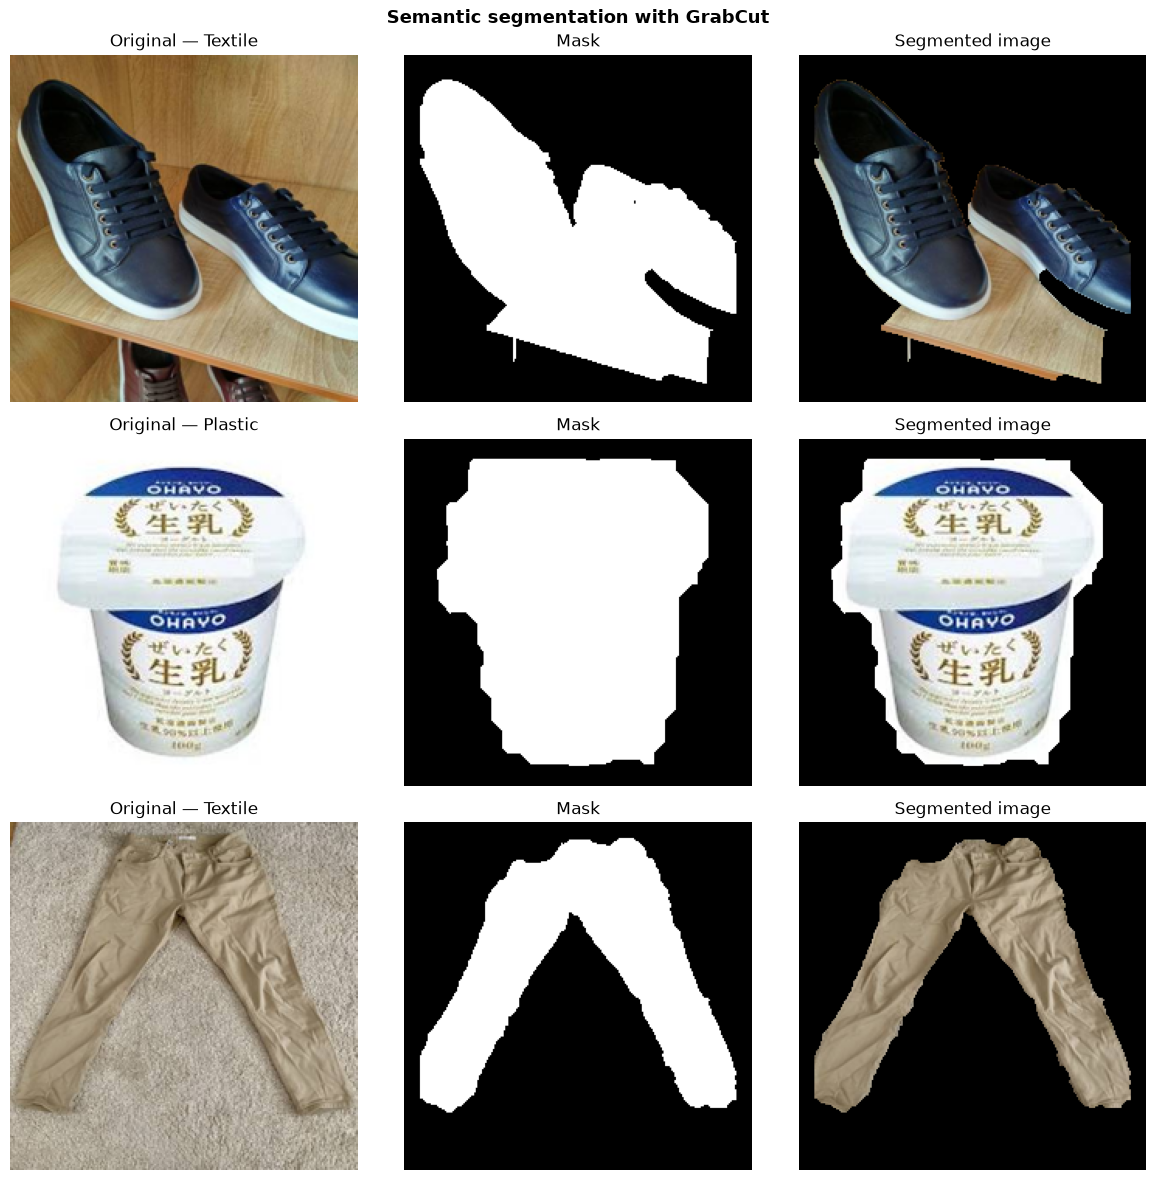

In [13]:
# Visual demo on 3 images from different classes
number_of_images = 3
demo_indices = random.sample(range(len(full_dataset)), number_of_images)
fig, axes = plt.subplots(len(demo_indices), 3, figsize=(12, 4 * len(demo_indices)))
fig.suptitle("Semantic segmentation with GrabCut", fontsize=13, fontweight="bold")

for row, idx in enumerate(demo_indices):
    image, label = full_dataset[idx]
    original, mask, segmented = image_segmentation(image)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original — {IDX_TO_CLASS[label]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(segmented)
    axes[row, 2].set_title("Segmented image")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

---
## c) Preprocessing

The standard ImageNet parameters are used (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) since the downstream classifier will use a pretrained model (ResNet/EfficientNet).

**Train pipeline:**
`Resize(224)` → *augmentations* → `ToTensor` → `Normalize`

**Validation/test pipeline:**
`Resize(224)` → `ToTensor` → `Normalize`

> Augmentations are applied **only** to train, never to validation or test.

---
## d) Data Augmentation

### Transformations applied to the training set

| Transformation | Rationale for this problem |
|---|---|
| `RandomHorizontalFlip` | Waste has no canonical orientation; a flipped bottle is still a bottle. |
| `RandomRotation(15°)` | Objects are photographed from different angles; small rotations are realistic. |
| `ColorJitter(b=0.2, c=0.2, s=0.2)` | Lighting conditions vary widely (indoor/outdoor, flash, shadows). |

No vertical flip or aggressive cropping is applied because they could remove identifying parts of the object (e.g., labels on plastics).

In [14]:
# Transforms for training (with data augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transforms for validation and test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms defined")
print("   Train:       resize + flip + rotation + color jitter + tensor + norm")
print("   Val / Test:  resize + tensor + norm")

✅ Transforms defined
   Train:       resize + flip + rotation + color jitter + tensor + norm
   Val / Test:  resize + tensor + norm


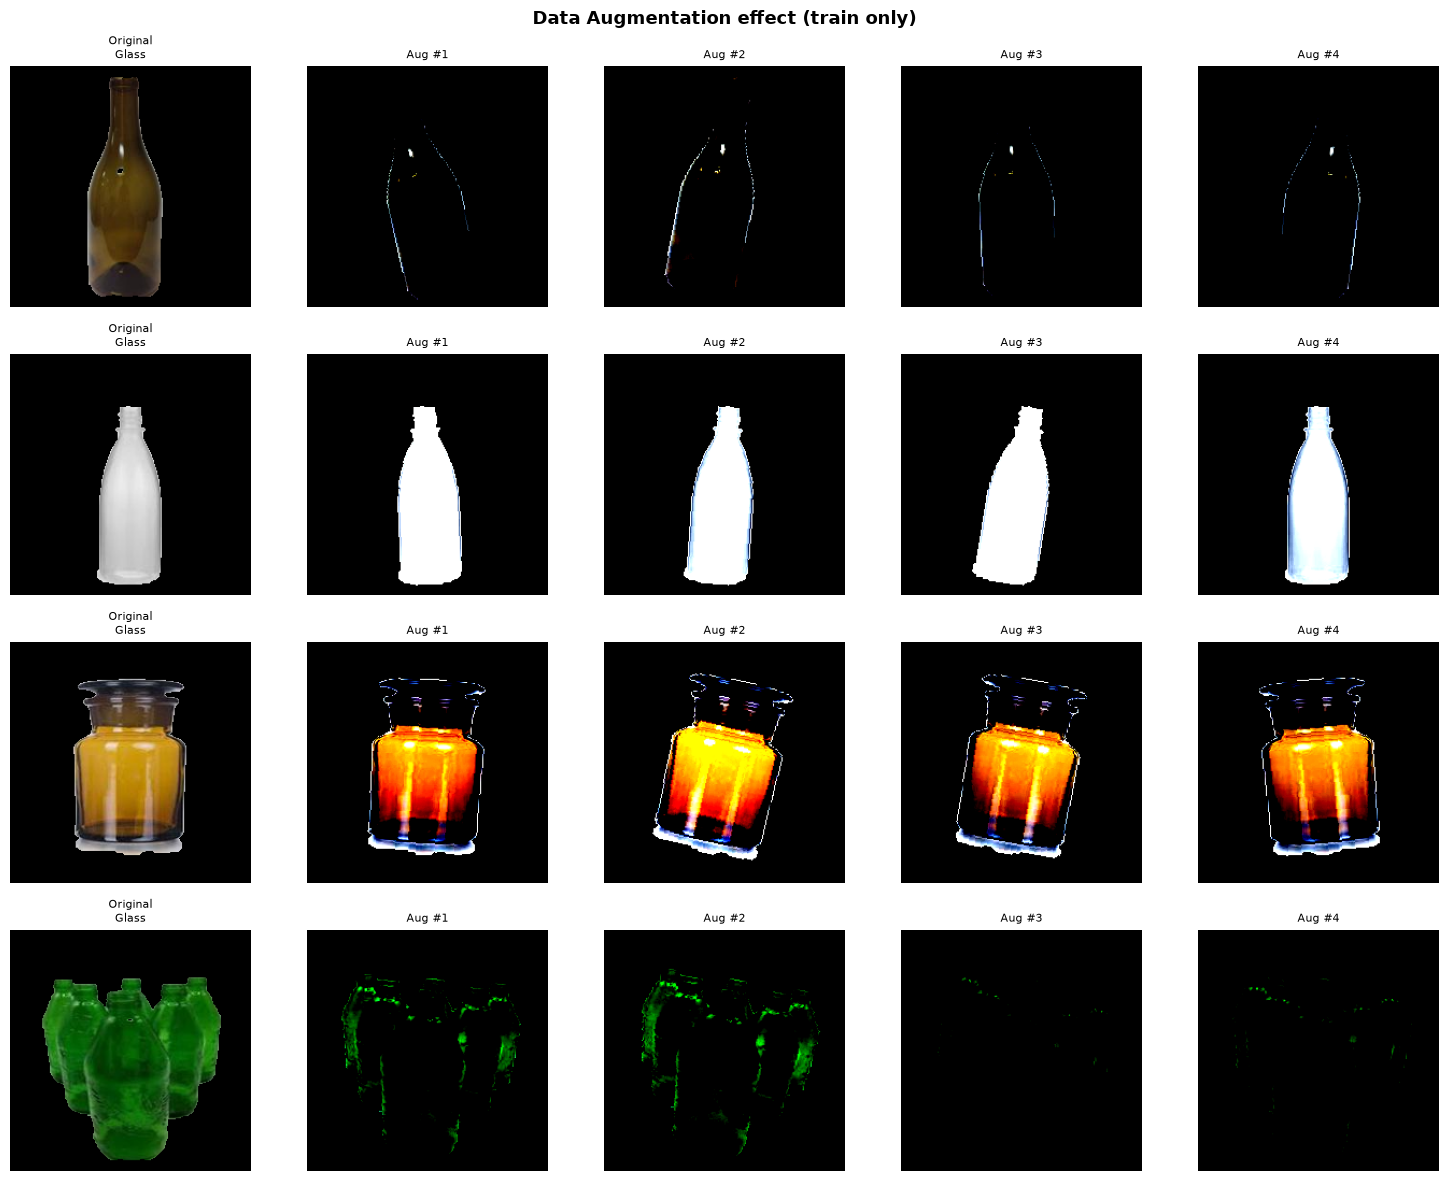

In [15]:
# Visualization of the augmentation effect on 4 different images
sample_indices = [0, 150, 400, 900]
n_versions     = 4   # augmented versions per image

fig, axes = plt.subplots(
    len(sample_indices),
    n_versions + 1,
    figsize=(3 * (n_versions + 1), 3 * len(sample_indices))
)
fig.suptitle("Data Augmentation effect (train only)", fontsize=13, fontweight="bold")

for row, idx in enumerate(sample_indices):
    image, label = full_dataset[idx]
    _, _, seg = image_segmentation(image)
    seg_pil = Image.fromarray(seg)

    # Column 0: segmented original
    axes[row, 0].imshow(seg)
    axes[row, 0].set_title(f"Original\n{IDX_TO_CLASS[label]}", fontsize=8)
    axes[row, 0].axis("off")

    # Columns 1..n_versions: augmented versions
    for col in range(1, n_versions + 1):
        aug_tensor = train_transforms(seg_pil)
        aug_np     = aug_tensor.permute(1, 2, 0).numpy()
        aug_np     = np.clip(aug_np, 0, 1)
        axes[row, col].imshow(aug_np)
        axes[row, col].set_title(f"Aug #{col}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

---
## Final PyTorch Dataset (`WasteDataset`)

`WasteDataset` is implemented, inheriting from `torch.utils.data.Dataset` and encapsulating:
1. Access to the unified dataset images via split indices.
2. Semantic segmentation applied in `__getitem__`.
3. Application of the corresponding transform (train vs. val/test).

In [16]:
class WasteDataset(Dataset):
    """
    Final dataset for waste classification.
    Applies semantic segmentation and the transforms of the corresponding split.

    Args:
        base_dataset: a UnifiedGarbageDataset instance.
        indices:      list of split indices (train/val/test).
        transform:    torchvision.transforms.Compose to apply.
    """

    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indexes      = indices
        self.transform    = transform

    def __len__(self):
        return len(self.indexes)

    def __getitem__(self, idx):
        real_idx = self.indexes[idx]
        image, label = self.base_dataset[real_idx]

        # Segmentation: isolate the object from the background
        _, _, segmented_image = image_segmentation(image)
        segmented_pil = Image.fromarray(segmented_image)

        # Preprocessing + augmentations (if applicable)
        if self.transform:
            segmented_pil = self.transform(segmented_pil)

        return segmented_pil, label


train_dataset = WasteDataset(full_dataset, train_idx, transform=train_transforms)
val_dataset   = WasteDataset(full_dataset, val_idx,   transform=val_test_transforms)
test_dataset  = WasteDataset(full_dataset, test_idx,  transform=val_test_transforms)

print(f"✅ Datasets created:")
print(f"   Train:      {len(train_dataset)} samples")
print(f"   Validation: {len(val_dataset)}  samples")
print(f"   Test:       {len(test_dataset)}  samples")

✅ Datasets created:
   Train:      20975 samples
   Validation: 2622  samples
   Test:       2622  samples


---
## DataLoaders

| Parameter | Value | Reason |
|---|---|---|
| `batch_size` | 32 | Standard size; trade-off between training speed and VRAM usage. |
| `shuffle=True` | train | Prevents the model from always seeing the same classes in the same order per epoch. |
| `shuffle=False` | val/test | Metrics must be deterministic across evaluations. |
| `drop_last=True` | train | Avoids incomplete batches that could distort BatchNorm. |

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("✅ DataLoaders created")
print(f"   Train batches:      {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches:       {len(test_loader)}")

✅ DataLoaders created
   Train batches:      655
   Validation batches: 82
   Test batches:       82


---
## e) Final Pipeline Verification

A batch is pulled from the train DataLoader to confirm:
- Correct tensor dimensions `(batch_size, C, H, W)`.
- Value range after normalization (negative/positive values, not [0,1]).
- Correct correspondence between images and labels after denormalizing.

In [18]:
def denormalize(img_tensor):
    """Denormalize a (C,H,W) tensor with ImageNet stats for visualization."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.numpy().transpose((1, 2, 0))
    img  = std * img + mean
    return np.clip(img, 0, 1)

In [19]:
images_batch, labels_batch = next(iter(train_loader))

print("=== Batch verification ===")
print(f"Tensor shape:      {images_batch.shape}")
print(f"  batch_size={images_batch.shape[0]}, channels={images_batch.shape[1]}, "
      f"height={images_batch.shape[2]}, width={images_batch.shape[3]}")
print(f"Data type:         {images_batch.dtype}")
print(f"Range (post-norm): [{images_batch.min():.3f}, {images_batch.max():.3f}]")
print(f"Batch labels:      {labels_batch[:8].tolist()}")

=== Batch verification ===
Tensor shape:      torch.Size([32, 3, 224, 224])
  batch_size=32, channels=3, height=224, width=224
Data type:         torch.float32
Range (post-norm): [-2.118, 2.640]
Batch labels:      [8, 1, 4, 8, 1, 7, 1, 8]


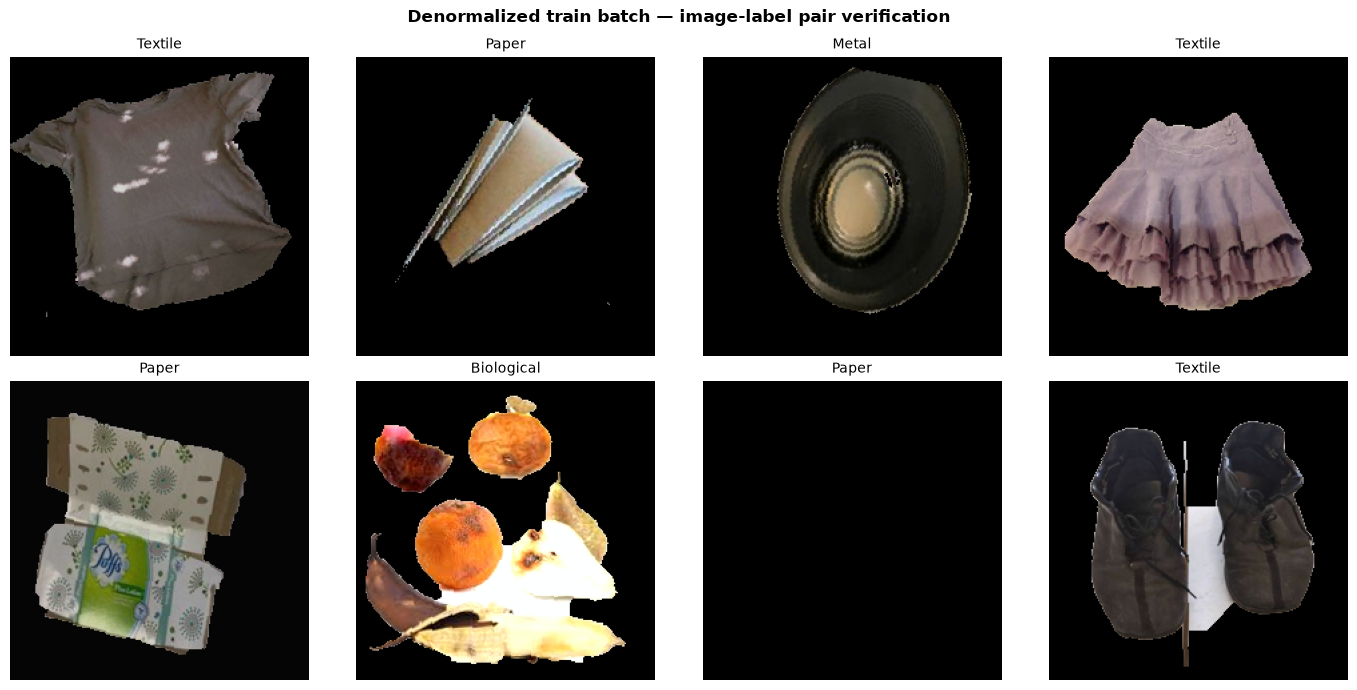


✅ Pipeline complete and verified.
   Image-label pairs are correct.
   The notebook is ready for the fine-tuning stage.


In [20]:
# Visualization of 8 images from the batch with their labels (denormalized)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(
    "Denormalized train batch — image-label pair verification",
    fontsize=12, fontweight="bold"
)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(denormalize(images_batch[i]))
    ax.set_title(IDX_TO_CLASS[labels_batch[i].item()], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Pipeline complete and verified.")
print("   Image-label pairs are correct.")
print("   The notebook is ready for the fine-tuning stage.")

In [21]:
# Extract paths and labels from the original dataset
all_samples = full_dataset.samples  # returns a list of tuples: [(absolute_path, label_idx), ...]

def format_path(abs_path):
    if EXECUTION_MODE == "local":
        # Path relative to 'data/raw', resolved from the parent directory
        raw_dir = os.path.abspath("../data/raw")
        return os.path.relpath(abs_path, raw_dir).replace("\\", "/")
    else:
        # Online mode: use the absolute cache path (avoids ValueError across drives)
        return abs_path

# Build lists of dictionaries with the path according to the mode
train_data = [{"path": format_path(all_samples[i][0]), "label": all_samples[i][1], "split": "train"} for i in train_idx]
val_data   = [{"path": format_path(all_samples[i][0]), "label": all_samples[i][1], "split": "val"} for i in val_idx]
test_data  = [{"path": format_path(all_samples[i][0]), "label": all_samples[i][1], "split": "test"} for i in test_idx]

# Create the data folder at the project root
os.makedirs("../data", exist_ok=True)

# Save to CSV
pd.DataFrame(train_data).to_csv("../data/train.csv", index=False)
pd.DataFrame(val_data).to_csv("../data/val.csv", index=False)
pd.DataFrame(test_data).to_csv("../data/test.csv", index=False)

print("✅ CSV files successfully generated in ../data/")

✅ CSV files successfully generated in ../data/
